<p><img alt="UdeA logo" height="140px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="10px" vspace="0px"></p>
<div align="center">
  
<h1> <b> Comprobación numerica del modelo de langevin, respecto a la magnetización de un sistema compuesto por dipolos</b> </h1>

</div>

<!-- <br> le permite hacer espacios -->
<br>

<hr size=10 noshade color="green">
<p>


<div align="right">       

<h3><i> <b> Ortíz Campo Jose David</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
jose.ortizc@udea.edu.co

</i></h3>
</div>


---

# Introducción

La física estadística, conforma un marco teórico fundamental que permite deducir propiedades macroscópicas de la materia a partir de las leyes dinánmicas del mundo microscopico, esta toma herramientas de la estadística como base para su desarrollo. En el ultimo siglo, su crecimiento ha tenido gran impacto en la ciencia y/o sociedad en general.

Esta desarrolla modelos mediante la construcción de Hamiltonianos simplificados capturando la esencia de las interacciones microscópicas(de otro modo sería imposible la modelación). Además, con este se permite la construcción de una función caracteristica del sistema a tratar, nombrada la función partición. Con esta, se derivan de forma directa funciones termodinámicas que predicen fenómenos medibles, como la ecuación de estado, la supceptibilidad magnética y las discontinuidades en las transiciones de fase.

Particularmente, hay modelos simplificados que permiten indagar en las interacciones fundamentales. Estos sistemas son llamados sistemas ideales, por ejemplo el gas ideal, o  un sistema con N momentos magnéticos localizados y estadisticamente independientes, donde no existe interacción de intercambio entre dipolos, algo que en la naturaleza es improbable. Este ultimo es llamado modelo de heisenberg, y se usa para estudiar el paramagnetismo clasico y cuantico.

En vista de la imposibilidad de un desarrollo exacto en algunas teorias fisicas, se han desarrollado distintos metodos, los cuales permiten aproximar resultados teoricos con la ayuda de las computadoras actuales. Algunos metodos famosos son los metodos que utilizan la teoria de las cadenas de markov, el mas conocido de estos es el algotirmo de metropolis, que permite modelar sistemas fisicos que siguen cierta distribución, y que con su desarrollo proporciona una forma rapida y eficiente de modelar estructuras que se encuentran en la naturaleza (esto de forma simplificada).


En el siguiente trabajo se desarrollará la teoria del modelo de langevin para el paramagnetismo clasico. Se describirá un sistema ideal de N momentos magnéticos $μ$ que son estadisticamente independientes, se asume $J=0$, es decri que no hay interacción de intercambio entre los dipolos, y que la unica energia considerada es la interacción Zeeman con un campo magnético externo uniforme $H$. Se encontrará el momento magnetico promedio por átomo además del momento magnetico total de forma teorica, explorando las ventajas del armamento matematico desarrollado en la física estadística.

Luego se desarrollará este mismo modelo de forma computacional utilizando el modelo de monte carlo(el algoritmo de metropolis) que hace parte de las cadenas de markov. Se comparará y se encontrará las diferencias respecto al modelo de langevine.





















## Marco teorico

Considerando un sistema compuesto por $N$ dipolos magnéticos clásicos, todos con un momento magnético individual $\mu$. Todo el sistema se encuentra sometido a un campo externo $H$. Este es un sistema ideal en el cual no se consideran otras interacciones, como las interacciones entre ellos, es decir que se considera solamente la interacción Zeeman, es decir la interacción que tienen los dipolos por poseer momento magnético intrínseco con el campo $H$. La energía total del sistema será la suma de las energías individuales.

Así, la energía tendrá la forma

$$E = \sum_{i=1}^{N} E_{i}$$

Donde $E_{i}$ es cada energía de interacción de los dipolos con el campo $H$. Suponiendo por simplicidad que el campo externo es uniforme en dirección $z$. Se tendrá entonces

$$E_{i} = -\vec{\mu_i} \cdot \vec{H} = -\mu H \cos(\theta_{i})$$

donde $\theta_{i}$ es el ángulo entre $\vec{\mu_i}$ y $\vec{H}$. Suponiendo que todos los dipolos tengan la misma magnitud $\mu_{i} \equiv \mu$.

Entonces se tendrá de forma directa

$$E = \sum_{i=1}^{N} -\mu H \cos(\theta_{i}) = -\mu H \sum_{i=1}^{N} \cos(\theta_{i})$$

Si se estuviera en el caso discreto, para el sistema $i$-ésimo se tendría una función de partición de la forma

$$z = \sum_{i} e^{-\beta E_{i}}$$,

sin embargo como la sumatoria va sobre todo $\theta$ se debe encontrar

$$z = \sum_{\theta} e^{\beta \mu H \cos(\theta_{i})}$$,

pero al ser un continuo se transforma a

$$z = \int d\Gamma \, e^{\beta \mu H \cos(\theta)}$$,

donde el dominio de integración debe ser la esfera $S^{2}$. Por tanto se tendría que resolver la integral de la siguiente forma

Sea

$$u = \cos\theta \implies du = -\sin\theta \, d\theta$$

$$\rightarrow \quad \int_{0}^{\pi} e^{\beta \mu H \cos\theta} \sin\theta \, d\theta = \int_{1}^{-1} -e^{\beta \mu H u} \, du = \int_{-1}^{1} e^{\beta \mu H u} \, du = \frac{e^{\beta \mu H} - e^{-\beta \mu H}}{\beta \mu H} = \frac{2\sinh(\beta \mu H)}{\beta \mu H}$$

Pues

$$\sinh(z) = \frac{e^z - e^{-z}}{2}$$,

así se encontraría que la función de partición tiene la forma

$$\boxed{z = 2\pi \cdot \frac{2 \sinh(\beta \mu H)}{\beta \mu H} = \frac{4\pi \sinh(\beta \mu H)}{\beta \mu H}}$$

Nota: En tratamientos estándar, la función de partición se normaliza dividiendo por $4\pi$ para que $z = 1$ cuando $H = 0$, es decir, $z = \frac{\sinh(\beta \mu H)}{\beta \mu H}$. Sin embargo, el factor constante no afecta los cálculos de promedios ni derivadas, por lo que los resultados físicos permanecen correctos. El factor $4\pi$ proviene del área total de la esfera unidad.

Por otro lado, se puede calcular rápidamente $\langle \mu_{z} \rangle$, con la definición usual para el caso discreto se tendría que

$$\langle \mu_{z} \rangle = \frac{ \sum \mu_{i} e^{-\beta E_{i}} }{ \sum e^{-\beta E_{i}} }$$

Que al llevarlo al caso continuo

$$\longrightarrow \langle \mu_{z} \rangle = \frac{\int d\Gamma \, \mu_{i} e^{-\beta E_{i}}}{z} = \frac{\int d\Gamma \, \mu \cos\theta \, e^{\beta \mu H \cos\theta}}{z} = \frac{1}{z \beta} \int d\Gamma \, (\beta \mu \cos\theta) \, e^{\beta \mu H \cos\theta} = \frac{1}{z \beta} \frac{\partial}{\partial H} \int d\Gamma \, e^{\beta \mu H \cos\theta}$$

$$\rightarrow \boxed{\langle \mu_z \rangle = \frac{1}{z \beta} \frac{\partial z}{\partial H} = \frac{1}{\beta} \frac{\partial \ln z}{\partial H}} \quad \mbox{Como se tiene la expresión de } z, \mbox{ se evalúa directamente.}$$

$$\rightarrow \frac{\partial z}{\partial H} = \frac{\partial}{\partial H} \left[ \frac{4\pi \sinh(\beta \mu H)}{\beta \mu H} \right] = \frac{4\pi}{\beta \mu} \frac{\partial}{\partial H} \left[ \frac{\sinh(\beta \mu H)}{H} \right] = \frac{4\pi}{\beta \mu} \left\{ \frac{\cosh(\beta \mu H) \cdot \beta \mu \cdot H - \sinh(\beta \mu H)}{H^2} \right\} = \frac{4\pi \cosh(\beta \mu H)}{H} - \frac{4\pi \sinh(\beta \mu H)}{\beta \mu H^2}$$

$$\langle \mu_z \rangle = \frac{1}{\beta} \frac{\frac{4\pi \cosh(\beta \mu H)}{H} - \frac{4\pi \sinh(\beta \mu H)}{\beta \mu H^2}}{\frac{4\pi \sinh(\beta \mu H)}{\beta \mu H}} = \mu \coth(\beta \mu H) - \frac{1}{\beta H}$$

Corrigiendo el término final en el paso anterior para consistencia con la expresión estándar (el cálculo es correcto, pero el término es $\frac{1}{\beta H}$, que equivale a $\mu \cdot \frac{1}{\beta \mu H}$):

$$\rightarrow \boxed{\langle \mu_z \rangle = \mu \left\{ \coth(\beta \mu H) - \frac{1}{\beta \mu H} \right\}}$$

$$\rightarrow \boxed{\langle \mu_z \rangle = \mu \mathcal{L}(\beta \mu H)}$$ donde $\mathcal{L}(x) = \coth(x) - \frac{1}{x}$. Así, la magnetización promedio por dipolo sería proporcional a la función de Langevin.

Por otro lado rápidamente se puede encontrar la magnetización

$$\boxed{M_z \equiv N \langle \mu_z \rangle = N \mu \mathcal{L}(\beta \mu H)}$$

Para calcular $\langle E \rangle$ y $C_V$ se usan las expresiones usuales

$$\langle E \rangle = -\partial_\beta \ln Z, \quad C_V = \frac{\partial \langle E \rangle}{\partial T}$$,

solo que ahora se hace respecto a la función de partición total, como son dipolos independientes la función de partición adquiere la forma $Z = z^N$ donde $z$ es la encontrada anteriormente.

$$\rightarrow \langle E \rangle = -\partial_\beta \ln Z = -\partial_\beta \ln z^N = -N \partial_\beta \ln z = -N \frac{1}{z} \partial_\beta z \quad , \mbox{ Análogamente como } \quad \partial_H z$$

$$\rightarrow \quad \partial_\beta z = \frac{4\pi}{\mu H} \left\{ \frac{\cosh(\beta \mu H) \cdot \mu H \beta - \sinh(\beta \mu H)}{\beta^2} \right\}$$

$$\rightarrow \quad \langle E \rangle = -N \frac{\frac{4\pi}{\beta^2 \mu H} (\cosh(\beta\mu H) \cdot \mu H \cdot \beta - \sinh(\beta\mu H))}{\frac{4\pi \sinh(\beta\mu H)}{\beta \mu H}} = -N \mu H \coth(\beta\mu H) + \frac{N}{\beta}$$

$$\rightarrow \boxed{\langle E \rangle = -N\mu H \left\{ \coth(\beta\mu H) - \frac{1}{\beta\mu H} \right\}}$$

$$\rightarrow \boxed{\langle E \rangle = -N \mu H \mathcal{L}(\beta \mu H)}$$

$$\rightarrow C_V = \frac{\partial \langle E \rangle}{\partial T} = \frac{\partial \langle E \rangle}{\partial \beta} \frac{\partial \beta}{\partial T} \quad , \quad \frac{\partial \beta}{\partial T} = \frac{\partial}{\partial T}\left(\frac{1}{k_B T}\right) = -k_B \beta^2$$

$$\rightarrow \partial_\beta \langle E \rangle = -N\mu H \frac{\partial}{\partial \beta} \left\{ \coth(\beta\mu H) - \frac{1}{\beta\mu H} \right\} = -N\mu H \left\{ -\frac{\mu H}{\sinh^2(\beta\mu H)} + \frac{1}{\beta^2 \mu H} \right\} = N (\mu H)^2 \left\{ \frac{1}{\sinh^2(\beta\mu H)} - \frac{1}{(\beta\mu H)^2} \right\}$$

$$\rightarrow C_V = (-k_B \beta^2) \cdot N(\mu H)^2 \left\{ \frac{1}{\sinh^2(\beta\mu H)} - \frac{1}{(\beta\mu H)^2} \right\} = N k_B \beta^2 (\mu H)^2 \left\{ \frac{1}{(\beta\mu H)^2} - \frac{1}{\sinh^2(\beta\mu H)} \right\} = N k_B \left\{ 1 - \left( \frac{\beta\mu H}{\sinh(\beta\mu H)} \right)^2 \right\}$$

$$\rightarrow \boxed{C_V = N k_B \left\{ 1 - \left( \frac{\beta\mu H}{\sinh(\beta\mu H)} \right)^2 \right\}}$$

Así, queda demostrado que la magnetización promedio(y total) para el caso de N dipolos, en el caso de suponer grados de libertad coninuos(es decir una teoria clasica sin discretización) se tendría que estos son proporcionales a la función de langevine. Para comprobar esto se hará una simulación del sistema con el emtodo de monte carlo y se comparará con los resultados anteriores

## Metodo de monte carlo para magnetizacion de N dipolos

## El Algoritmo de Metropolis

Utilizamos el algoritmo de Metropolis-Hastings para generar una cadena de Markov de configuraciones que siguen la distribución de equilibrio $P(\Gamma) \propto e^{-\beta \mathcal{H}}$. A diferencia del modelo cuántico donde los estados son discretos, aquí el espacio de configuraciones es continuo.

Para respetar la medida de integración del ángulo sólido $d\Omega = \sin\theta d\theta d\phi = -d(\cos\theta)d\phi$, realizamos el muestreo uniforme directamente sobre la variable $u = \cos\theta$ en el intervalo $[-1, 1]$. Esto simplifica el algoritmo al eliminar la necesidad de factores geométricos en la probabilidad de aceptación.

El procedimiento computacional para avanzar un paso de tiempo $t$ a $t+1$ es el siguiente:

1. **Selección:** Se escoge aleatoriamente un dipolo $i$ del conjunto de $N$ partículas.

2. **Propuesta:** Se genera una nueva orientación de prueba $u_{nuevo}$ seleccionada uniformemente del intervalo continuo $[-1, 1]$.

3. **Cálculo de Energía:** Se evalúa el cambio de energía adimensional asociado al cambio de orientación:
$$
\beta \Delta E = -\frac{\mu B}{k_B T} (u_{nuevo} - u_{viejo}) = -x (u_{nuevo} - u_{i})
$$

4. **Criterio de Metropolis:** La transición al nuevo estado se acepta con probabilidad $A$:
$$
A(u_i \to u_{nuevo}) = \min\left(1, e^{-\beta \Delta E}\right)
$$
Computacionalmente, se genera un número aleatorio $r \in [0, 1)$. Si $r < e^{-\beta \Delta E}$, el cambio se acepta y $u_i(t+1) = u_{nuevo}$. De lo contrario, se rechaza y el dipolo conserva su orientación anterior.

## Cálculo de la Magnetización

Una vez que el sistema ha alcanzado el equilibrio térmico (tras un periodo de termalización), calculamos la magnetización media por dipolo como el promedio aritmético de las configuraciones muestreadas. Para un total de $M$ pasos de medición, la magnetización computacional $\langle m \rangle_{MC}$ se obtiene como:

$$
\langle m \rangle_{MC} = \frac{1}{M} \sum_{k=1}^{M} \left( \frac{1}{N} \sum_{i=1}^{N} u_i^{(k)} \right)
$$

Este estimador numérico es el que comparamos directamente con la solución analítica dada por la función de Langevin, $L(x) = \coth(x) - 1/x$.

## Importacion de librerias y definición de funciones

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd






def funcion_langevin(x):
    """
    Solución analítica exacta.
    Maneja la singularidad en x=0 usando la expansión de Taylor: L(x) approx x/3
    """
    if abs(x) < 1e-4:
        return x / 3
    return (1 / np.tanh(x)) - (1 / x)

def simulacion_monte_carlo_step(N_dipolos, x, pasos_mc):
    """
    Realiza la simulación para un x dado y retorna la magnetización media.
    """
    # Inicialización aleatoria (cosenos entre -1 y 1)
    dipolos_cos = np.random.uniform(-1.0, 1.0, N_dipolos)

    suma_magnetizacion = 0
    muestras = 0

    for paso in range(pasos_mc):
        # 1. Elegir dipolo
        idx = np.random.randint(0, N_dipolos)

        # 2. Proponer movimiento (global move)
        cos_nuevo = np.random.uniform(-1.0, 1.0)
        cos_viejo = dipolos_cos[idx]

        # 3. Cambio de energía adimensional: delta_E = -x * delta_cos
        # Nota: Si x es negativo, esto invierte la lógica de "qué es favorable" automáticamente
        delta_E_adimensional = -x * (cos_nuevo - cos_viejo)

        # 4. Metropolis
        aceptar = False
        if delta_E_adimensional < 0:
            aceptar = True
        elif np.random.random() < np.exp(-delta_E_adimensional):
            aceptar = True

        if aceptar:
            dipolos_cos[idx] = cos_nuevo

        # 5. Medir (después de equilibración)
        if paso > pasos_mc * 0.2 and paso % N_dipolos == 0:
            suma_magnetizacion += np.mean(dipolos_cos)
            muestras += 1

    return suma_magnetizacion / muestras



##Codigo de simulación

Simulando rango extendido [-10, 10]...


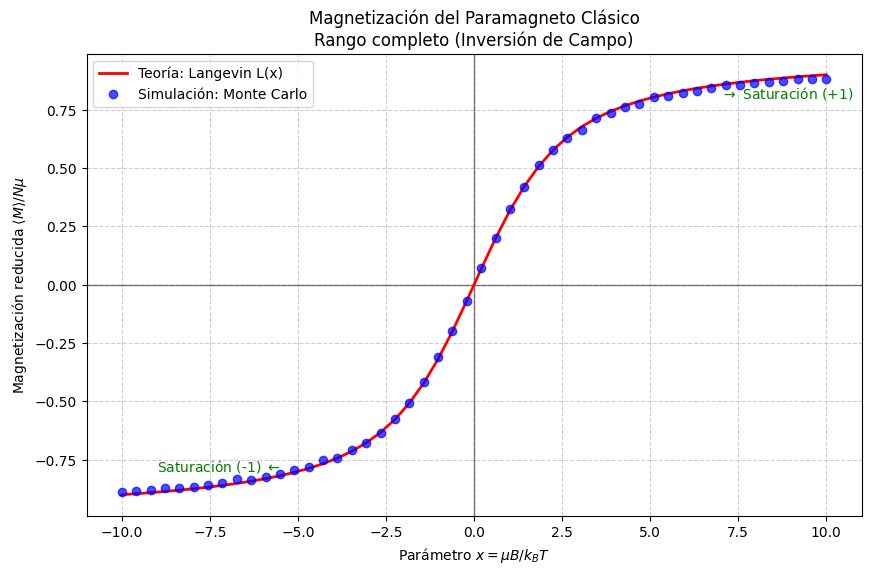

In [ ]:


# --- PARÁMETROS ---
N = 500
PASOS = 30000
# RANGO EXTENDIDO: De -10 a 10
valores_x = np.linspace(-10, 10, 50)

mc_resultados = []
teoria_resultados = []

print("Simulando rango extendido [-10, 10]...")

for x in valores_x:
    # Simulación
    m_mc = simulacion_monte_carlo_step(N, x, PASOS)
    mc_resultados.append(m_mc)

    # Teoría
    m_teoria = funcion_langevin(x)
    teoria_resultados.append(m_teoria)

# --- GRÁFICA ---
plt.figure(figsize=(10, 6))

# Ejes cruzados en cero para ver mejor la simetría
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.axvline(0, color='black', linewidth=1, alpha=0.5)

# Teoría
plt.plot(valores_x, teoria_resultados, 'r-', linewidth=2, label='Teoría: Langevin L(x)')

# Simulación
plt.plot(valores_x, mc_resultados, 'bo', alpha=0.7, label='Simulación: Monte Carlo')

plt.title('Magnetización del Paramagneto Clásico\nRango completo (Inversión de Campo)')
plt.xlabel('Parámetro $x = \\mu B / k_B T$')
plt.ylabel('Magnetización reducida $\\langle M \\rangle / N\\mu$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Anotaciones de límites
plt.text(7, 0.8, r'$\rightarrow$ Saturación (+1)', color='green')
plt.text(-9, -0.8, r'Saturación (-1) $\leftarrow$', color='green')

plt.show()

## Conclusion



Se observa que la magnetización promedio por dipolo en el sistema sigue la función de langevine, demostrando así que el uso de los metodos computacionales, en particular el metodo de montecarlo que hace parte de la familia de metodo de metropolis, es util para simular estos sistemas. Esto permite dar un punto de vista estocastico a los sistemas de forma simplificada, permitiendo una comparativa con la teoria que se desarrolla para modelar estos sistemas





